# Expected Credit Loss

Now that we have built a model for the $PD$ and chosen a fixed value for the $LGD$, we can calculate the $ECL$ (expected credit loss). This is an arithmetic exercise. Recall the formula: $$ECL=PD\cdot LGD \cdot EAD.$$

Let us first load our previous work.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#load PD results from 03
pd_results = pd.read_csv('data/pd_results.csv', index_col=0)

#load LGD from 04
lgd_value = pd.read_csv('data/lgd.csv')['lgd'][0]

#print amount of loans loaded and LGD value
print(f'Loaded {len(pd_results)} loans')
print(f'LGD: {lgd_value:.4f}')
print(pd_results.head())

Loaded 19962 loans
LGD: 0.9304
         loan_amnt  term  int_rate  installment  sub_grade  emp_length  \
1564941    35000.0    60     13.58       806.79         12        10.0   
1184447    12000.0    36     14.49       413.00         14         2.0   
1374751    13300.0    36     16.91       473.59         15         0.0   
1758200     8000.0    36     16.99       285.19         16         8.0   
1625367     3000.0    36      6.62        92.12          2         2.0   

         annual_inc    dti  delinq_2yrs  fico_range_low  ...  mort_acc  \
1564941     71805.0   4.40          0.0           660.0  ...       3.0   
1184447    102000.0   1.62          0.0           705.0  ...       0.0   
1374751     40000.0  54.94          2.0           675.0  ...       3.0   
1758200     65000.0  25.70          0.0           670.0  ...       0.0   
1625367     88668.0   3.30          0.0           790.0  ...       1.0   

         pub_rec_bankruptcies  home_ownership_MORTGAGE  home_ownership_OWN  \
1

We see that our predicted $PD$ for each loan and fixed $LGD$ have both loaded.

Now, let us compute the $ECL$. We first compute the $EAD$ (exposure at default) by summing the outstanding balance of each loan at our point in time. Recall that we have taken a model assumption to be that the outstanding amount at default is the full amount. So we sum the `funded_amnt` column.

In [21]:
#EAD is the full funded amount, we sum
pd_results['ead'] = pd_results['loan_amnt']

Now we calculate the $ECL$ using the formula.

In [22]:
#calculate ECL
pd_results['ecl'] = pd_results['pd_predicted']*lgd_value*pd_results['ead']

#sum ECL
total_ecl = pd_results['ecl'].sum()

#print ECL
print(pd_results['ecl'])
print(f'Total expected credit loss: £{total_ecl:,.0f}')

#sum exposure
total_exposure = pd_results['ead'].sum()
#print exposure
print(f'Total portfolio exposure: £{total_exposure:,.0f}')
#print ecl as proportion of exposure
print(f'Expected credit loss as % of exposure: {(total_ecl/total_exposure)*100:.2f}%')

1564941    4123.345316
1184447    1787.658618
1374751    2120.494730
1758200    1103.993680
1625367      62.003543
              ...     
1612043     920.957638
1233699    1030.522867
1193816    3621.105771
562849      348.587420
1214650    3300.588285
Name: ecl, Length: 19962, dtype: float64
Total expected credit loss: £38,680,603
Total portfolio exposure: £299,557,250
Expected credit loss as % of exposure: 12.91%


So we now have a value for our expected credit loss based on our dataset. We note that this value is slightly less than the default rate. This is to be expected, the slight reduction is likely due to the recoveries from some of the defaulted loans.

Let us plot a summary chart.

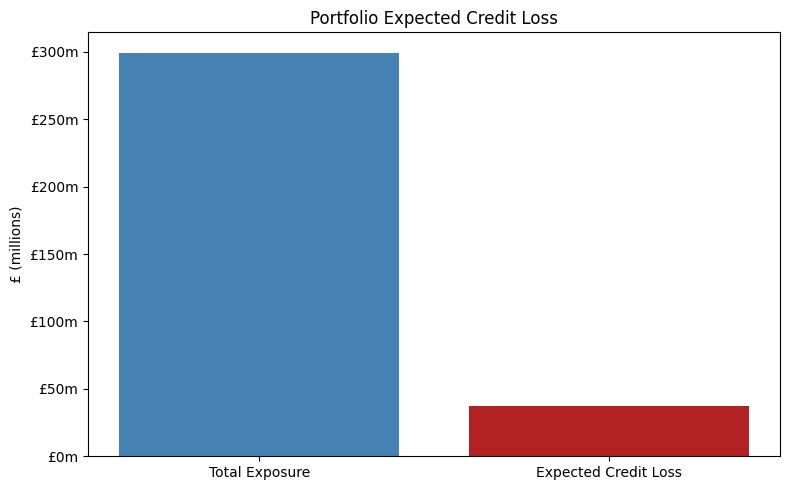

In [23]:
import matplotlib.ticker as mticker

#summary bar chart
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(categories, values, color=['steelblue', 'firebrick'])
#change y-axis values to be more readable
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.0f}m'))
ax.set_ylabel('£ (millions)')
ax.set_title('Portfolio Expected Credit Loss')
plt.tight_layout()
plt.show()

So we see that a loss provision should be made for $12.91\%$ of the total exposure, which amounts to £$38680603$. This provision assumes that external factors persist. We shall see later when we begin to shock this model that this may not be a strong assumption in the modern geopolitical climate.

Let us save these results.

In [ ]:
#save ECL results for later use
pd_results.to_csv('data/ecl_results.csv', index=True)
print(f'Saved {len(pd_results)} rows to ecl_results.csv')

Saved 19962 rows to ecl_results.csv


: 